Name: Lama Alfreah.

# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [2]:
df= pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv")
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
data = df[['Experience Years']]  # DataFrame feature
target = df['Salary']             # target

### Step 2.b print the type of each

In [4]:
display(df['Experience Years'] .dtype)
display(df['Salary'] .dtype)

dtype('float64')

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Target is numerical value and task is regression 

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [6]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

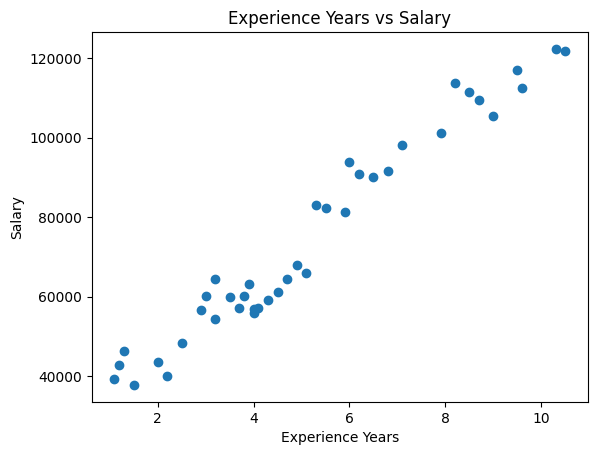

In [7]:
import matplotlib.pyplot as plt

plt.scatter(data, target)
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience Years vs Salary")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship between the feature and the target is increasing.

### Step 7. Initialize a regression model

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, target,
    test_size=0.20,
    random_state=42,
)

### Step 9.a Train the model on the training set

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [11]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 9408.031272506578
Intercept: 26716.25017614555


### Step 9.c how much salary does a person get with 2 years of experience?

In [12]:
salary_2_years = slope * 2 + intercept
print(salary_2_years)

45532.312721158705


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [13]:
increase = slope * (1/2)
print(increase)

4704.015636253289


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [14]:
print(intercept)

26716.25017614555


### Step 10. Evaluate the model on the test set

In [15]:
from sklearn.metrics import r2_score

predicted = model.predict(X_test)
print(r2_score(y_test, predicted))

0.9068577573647874


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [16]:
sample_X = X_test.head(3)
sample_y = y_test.head(3)

pred = model.predict(sample_X)

print("Predicted:", pred)
print("Actual:", sample_y.values)

Predicted: [69052.39090243 64348.37526617 64348.37526617]
Actual: [61111 56957 55794]


### Step 12. Plot the data and the regression line

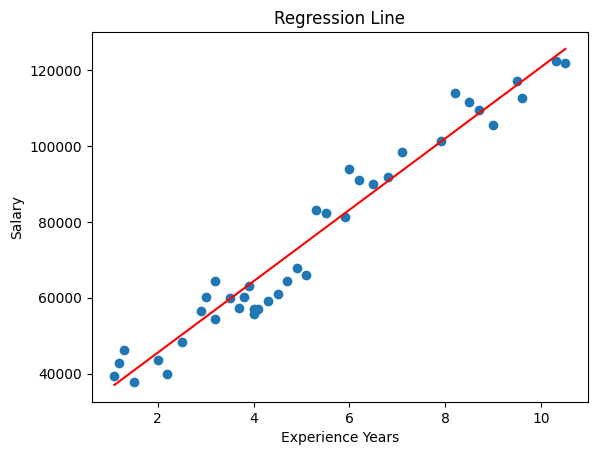

In [17]:
plt.scatter(data, target)
plt.plot(data, model.predict(data), color='red')
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()